# The analysis here have been borrowed from: https://www.kaggle.com/code/harshaaharshini/analysis-on-aviation-accidents

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Data Loading and Exploration

In [2]:
data_path = r"c:\Users\neupa\OneDrive\Desktop\Fall 2025\DATA 621 - DATA COMMUNICATION AND VISUALIZATION\DATA-613-Aviation-Safety-Analysis\data\archive\AviationData.csv"
aviation_data = pd.read_csv(data_path, encoding='latin-1')
print(f"Dataset shape: {aviation_data.shape}")
print(f"\nColumn names and types:")
aviation_data.info()

Dataset shape: (88889, 31)

Column names and types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null 

In [5]:
aviation_data

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


### Data Overview Analysis

The dataset contains **88,889 aviation accident records** spanning from 1948 to 2022, with 31 variables capturing various aspects of each incident. Key observations:

- **Temporal coverage**: Full dates for all events, with event and publication dates
- **Geographic data**: Location, country, latitude/longitude
- **Aircraft information**: Make, model, engine type, amateur-built status
- **Severity metrics**: Injury categories, aircraft damage levels
- **Flight context**: Weather conditions, flight phase, purpose of flight
- **Data quality**: Some missing values in aircraft damage (3.6%), weather conditions (5.1%), and flight phase (30.5%)

## Damage-wise Aviation Accident Statistics Over the Years

In [6]:
aviation_data_for_analysis = aviation_data[['Event.Id', 'Event.Date', 'Location', 
                                             'Country', 'Weather.Condition', 'Aircraft.damage']].copy()

aviation_data_for_analysis['Event.Date'] = pd.to_datetime(aviation_data_for_analysis['Event.Date'], errors='coerce')
aviation_data_for_analysis['Event.year'] = aviation_data_for_analysis['Event.Date'].dt.year
aviation_data_for_analysis['Aircraft.damage'] = aviation_data_for_analysis['Aircraft.damage'].fillna('Unknown')

print(f"Data shape: {aviation_data_for_analysis.shape}")
print(f"\nAircraft damage categories:")
print(aviation_data_for_analysis['Aircraft.damage'].value_counts())

Data shape: (88889, 7)

Aircraft damage categories:
Aircraft.damage
Substantial    64148
Destroyed      18623
Unknown         3313
Minor           2805
Name: count, dtype: int64


In [8]:
damage_wise_stats = aviation_data_for_analysis.groupby(['Aircraft.damage', 'Country', 'Event.year']).size().reset_index(name='Num_of_Accidents')
damage_wise_stats = damage_wise_stats.sort_values('Event.year')
damage_wise_stats.head(10)

,Aircraft.damage,Country,Event.year,Num_of_Accidents
1076,Destroyed,United States,1948,1
1077,Destroyed,United States,1962,1
1078,Destroyed,United States,1974,1
1079,Destroyed,United States,1977,1
1080,Destroyed,United States,1979,1
2736,Substantial,United States,1979,1
1081,Destroyed,United States,1981,1
3448,Unknown,United States,1982,54
2534,Substantial,Puerto Rico,1982,2
2348,Substantial,MISSING,1982,1


In [10]:
aviation_data_for_analysis

,Event.Id,Event.Date,Location,Country,Weather.Condition,Aircraft.damage,Event.year
0,20001218X45444,1948-10-24,"MOOSE CREEK, ID",United States,UNK,Destroyed,1948
1,20001218X45447,1962-07-19,"BRIDGEPORT, CA",United States,UNK,Destroyed,1962
2,20061025X01555,1974-08-30,"Saltville, VA",United States,IMC,Destroyed,1974
3,20001218X45448,1977-06-19,"EUREKA, CA",United States,IMC,Destroyed,1977
4,20041105X01764,1979-08-02,"Canton, OH",United States,VMC,Destroyed,1979
...,...,...,...,...,...,...,...
88884,20221227106491,2022-12-26,"Annapolis, MD",United States,NaN,Unknown,2022
88885,20221227106494,2022-12-26,"Hampton, NH",United States,NaN,Unknown,2022
88886,20221227106497,2022-12-26,"Payson, AZ",United States,VMC,Substantial,2022
88887,20221227106498,2022-12-26,"Morgan, UT",United States,NaN,Unknown,2022


In [11]:
yearly_damage

,Event.year,Aircraft.damage,Num_of_Accidents
0,1948,Destroyed,1
1,1962,Destroyed,1
2,1974,Destroyed,1
3,1977,Destroyed,1
4,1979,Destroyed,1
...,...,...,...
166,2021,Unknown,227
167,2022,Destroyed,158
168,2022,Minor,41
169,2022,Substantial,1173


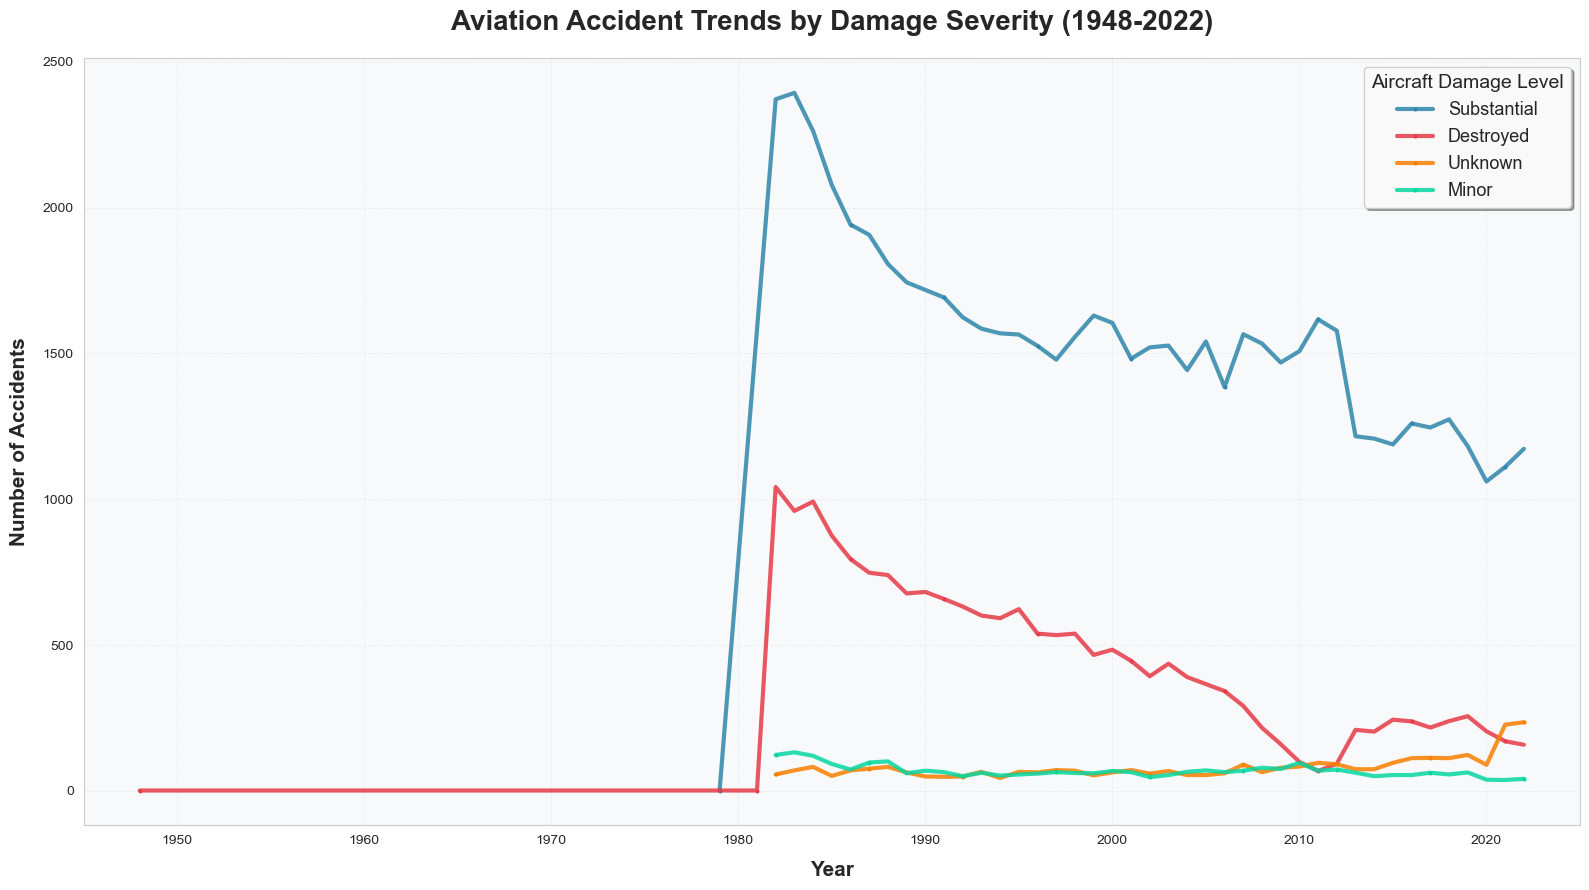

In [9]:
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

yearly_damage = aviation_data_for_analysis.groupby(['Event.year', 'Aircraft.damage']).size().reset_index(name='Num_of_Accidents')

colors = {
    'Substantial': '#2E86AB', 
    'Destroyed': '#E63946',   
    'Unknown': '#F77F00',     
    'Minor': '#06D6A0'        
}

for damage_type in ['Substantial', 'Destroyed', 'Unknown', 'Minor']:
    if damage_type in yearly_damage['Aircraft.damage'].unique():
        data_subset = yearly_damage[yearly_damage['Aircraft.damage'] == damage_type]
        ax.plot(data_subset['Event.year'], data_subset['Num_of_Accidents'], 
                label=damage_type, linewidth=3, color=colors.get(damage_type), 
                alpha=0.85, marker='o', markersize=2, markevery=5)

ax.set_xlabel('Year', fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel('Number of Accidents', fontsize=15, fontweight='bold', labelpad=10)
ax.set_title('Aviation Accident Trends by Damage Severity (1948-2022)', fontsize=20, fontweight='bold', pad=20)
ax.legend(title='Aircraft Damage Level', fontsize=13, title_fontsize=14, loc='upper right', framealpha=0.95, shadow=True)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
ax.set_xlim(1945, 2025)
ax.set_xticks(range(1950, 2025, 10))
plt.tight_layout()
plt.show()

### Analysis: Damage-wise Aviation Accident Trends

The visualization reveals several critical insights about aviation accident patterns over the 74-year period:

**Key Findings:**
1. **Peak Period (1982-1985)**: Aviation accidents reached their maximum during the early 1980s, with substantial damage accidents peaking at ~2,400 incidents per year
2. **Steady Decline Post-1985**: Both substantial and destroyed aircraft accidents have shown a consistent downward trend since the mid-1980s, indicating significant improvements in aviation safety
3. **Recent Improvements (2015-2022)**: The last decade shows the lowest accident rates in the entire dataset, with substantial damage accidents dropping to ~1,100 per year
4. **Damage Severity Distribution**: Throughout the period, Substantial damage consistently represents the majority of accidents, followed by Destroyed, suggesting most accidents are survivable
5. **Data Quality Improvement**: The spike in Unknown damage classifications around 2020 likely reflects reporting changes or COVID-19 pandemic impacts on data collection

**Safety Implications**: The dramatic 50% reduction in accidents from peak levels demonstrates the effectiveness of regulatory improvements, technological advances, and enhanced pilot training programs implemented over the past four decades.

## Impact of Weather Conditions on Damage Levels

Analysis of aircraft accidents in relation to weather conditions to identify patterns that contribute to aviation safety.

In [12]:
aviation_data_for_analysis

,Event.Id,Event.Date,Location,Country,Weather.Condition,Aircraft.damage,Event.year
0,20001218X45444,1948-10-24,"MOOSE CREEK, ID",United States,UNK,Destroyed,1948
1,20001218X45447,1962-07-19,"BRIDGEPORT, CA",United States,UNK,Destroyed,1962
2,20061025X01555,1974-08-30,"Saltville, VA",United States,IMC,Destroyed,1974
3,20001218X45448,1977-06-19,"EUREKA, CA",United States,IMC,Destroyed,1977
4,20041105X01764,1979-08-02,"Canton, OH",United States,VMC,Destroyed,1979
...,...,...,...,...,...,...,...
88884,20221227106491,2022-12-26,"Annapolis, MD",United States,NaN,Unknown,2022
88885,20221227106494,2022-12-26,"Hampton, NH",United States,NaN,Unknown,2022
88886,20221227106497,2022-12-26,"Payson, AZ",United States,VMC,Substantial,2022
88887,20221227106498,2022-12-26,"Morgan, UT",United States,NaN,Unknown,2022


In [13]:
# Clean weather condition data
aviation_data_for_analysis['Weather.Condition'] = aviation_data_for_analysis['Weather.Condition'].fillna('UNK')
aviation_data_for_analysis['Weather.Condition'] = aviation_data_for_analysis['Weather.Condition'].replace(['Unk', 'Unknown'], 'UNK')

# Check for missing values
print(f"Missing weather conditions: {aviation_data_for_analysis['Weather.Condition'].isna().sum()}")
print(f"\nWeather condition distribution:")
print(aviation_data_for_analysis['Weather.Condition'].value_counts())

Missing weather conditions: 0

Weather condition distribution:
Weather.Condition
VMC    77303
IMC     5976
UNK     5610
Name: count, dtype: int64


<b> VMC = Visual Metrological COnditions; this means good visibility 

IMC = Poor visibility due to fog/smoke/rain

UNK = Unknown 

In [15]:
weather_damage_report = aviation_data_for_analysis.groupby(['Weather.Condition', 'Aircraft.damage']).size().reset_index(name='number_of_accidents')
print(weather_damage_report.pivot_table(index='Weather.Condition', columns='Aircraft.damage', values='number_of_accidents', fill_value=0))

Aircraft.damage    Destroyed   Minor  Substantial  Unknown
Weather.Condition                                         
IMC                   3341.0   167.0       2257.0    211.0
UNK                   1516.0   649.0       2098.0   1347.0
VMC                  13766.0  1989.0      59793.0   1755.0


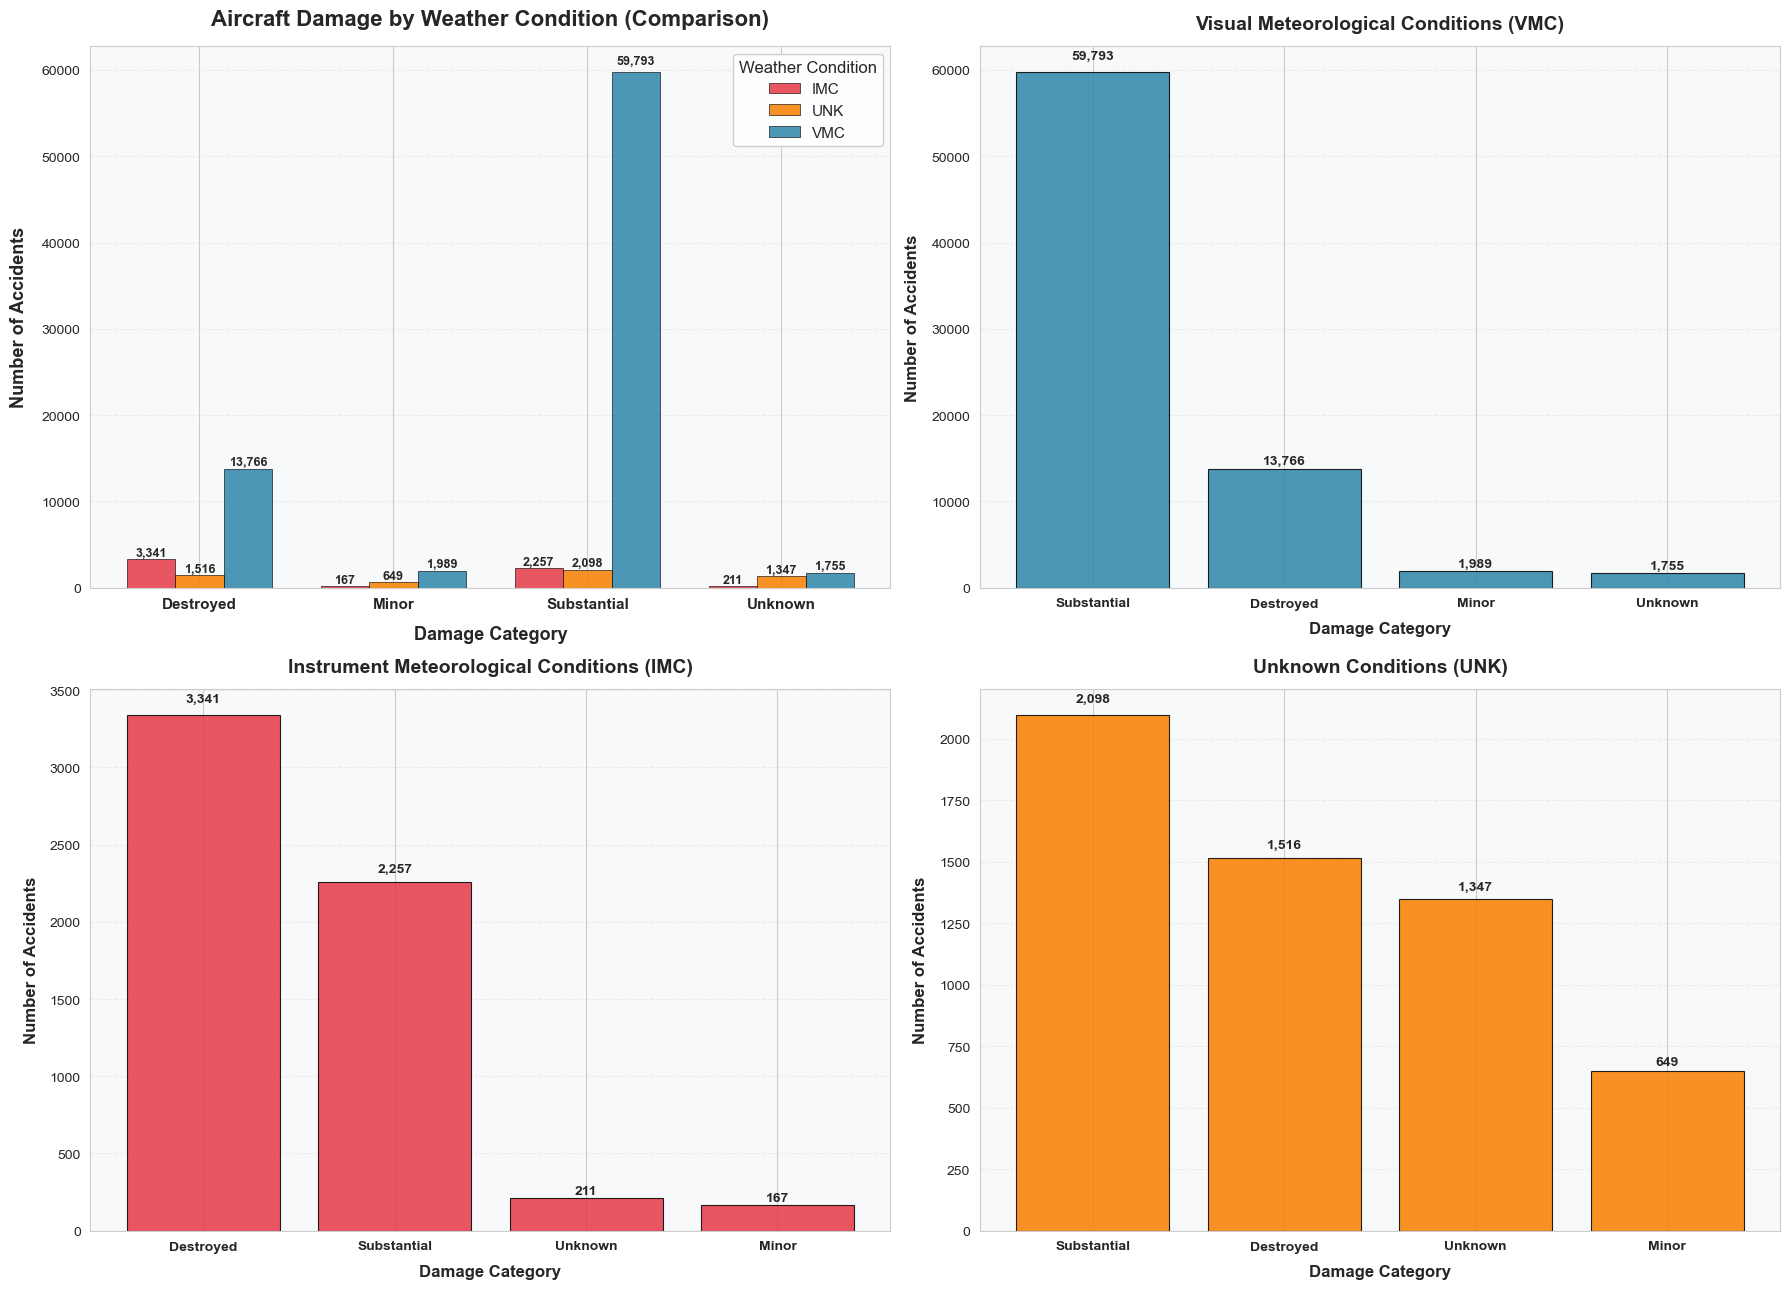

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13), dpi=100)
fig.patch.set_facecolor('white')

weather_colors = {'IMC': '#E63946', 'UNK': '#F77F00', 'VMC': '#2E86AB'}

weather_damage_pivot = weather_damage_report.pivot_table(
    index='Aircraft.damage', 
    columns='Weather.Condition', 
    values='number_of_accidents', 
    fill_value=0
)

x = np.arange(len(weather_damage_pivot.index))
width = 0.25

for i, weather in enumerate(['IMC', 'UNK', 'VMC']):
    offset = width * (i - 1)
    bars = axes[0, 0].bar(x + offset, weather_damage_pivot[weather], width, 
                          label=weather, color=weather_colors[weather], alpha=0.85, 
                          edgecolor='black', linewidth=0.5)
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                          f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0, 0].set_title('Aircraft Damage by Weather Condition (Comparison)', 
                     fontsize=16, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('Damage Category', fontsize=13, fontweight='bold', labelpad=10)
axes[0, 0].set_ylabel('Number of Accidents', fontsize=13, fontweight='bold', labelpad=10)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(weather_damage_pivot.index, fontsize=11, fontweight='bold')
axes[0, 0].legend(title='Weather Condition', fontsize=11, title_fontsize=12, framealpha=0.95)
axes[0, 0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0, 0].set_facecolor('#F8F9FA')
axes[0, 0].set_axisbelow(True)

weather_conditions = ['VMC', 'IMC', 'UNK']
positions = [(0, 1), (1, 0), (1, 1)]
weather_names = {
    'VMC': 'Visual Meteorological Conditions',
    'IMC': 'Instrument Meteorological Conditions', 
    'UNK': 'Unknown Conditions'
}

for weather, pos in zip(weather_conditions, positions):
    data = weather_damage_report[weather_damage_report['Weather.Condition'] == weather].copy()
    data = data.sort_values('number_of_accidents', ascending=False)
    
    bars = axes[pos].bar(range(len(data)), data['number_of_accidents'], 
                        color=weather_colors[weather], alpha=0.85, 
                        edgecolor='black', linewidth=0.8)
    
    axes[pos].set_title(f'{weather_names[weather]} ({weather})', 
                       fontsize=14, fontweight='bold', pad=12)
    axes[pos].set_xlabel('Damage Category', fontsize=12, fontweight='bold', labelpad=8)
    axes[pos].set_ylabel('Number of Accidents', fontsize=12, fontweight='bold', labelpad=8)
    axes[pos].set_xticks(range(len(data)))
    axes[pos].set_xticklabels(data['Aircraft.damage'], fontsize=10, fontweight='bold', rotation=0)
    axes[pos].grid(True, alpha=0.3, axis='y', linestyle='--')
    axes[pos].set_facecolor('#F8F9FA')
    axes[pos].set_axisbelow(True)
    
    for i, (bar, val) in enumerate(zip(bars, data['number_of_accidents'])):
        height = bar.get_height()
        axes[pos].text(bar.get_x() + bar.get_width()/2., height + height*0.02, 
                      f'{int(val):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Key Findings:**

1. **VMC Paradox - Substantial Damage Dominates**: Despite favorable weather conditions, VMC accounts for 59,793 substantial damage accidents (77% of all accidents). This counterintuitive finding suggests that:
   - Good weather may lead to pilot complacency
   - Most flights occur during VMC, increasing exposure
   - Recreational flying concentrates in good weather

2. **IMC - Highest Destruction Rate**: While IMC represents only 7% of total accidents, it shows a concerning pattern:
   - 56% of IMC accidents result in destroyed aircraft (3,341 destroyed vs 2,257 substantial)
   - This is significantly higher than VMC's 18% destruction rate
   - Poor visibility and weather increase severity when accidents occur

3. **Severity Comparison by Weather**:
   - **IMC**: 56% destroyed, 38% substantial, 3% minor
   - **VMC**: 18% destroyed, 77% substantial, 3% minor
   - Flying in instrument conditions is 3x more likely to result in total aircraft destruction

**Safety Implications:**
The data underscores that while most accidents happen in good weather (due to higher flight volume), accidents in poor weather conditions are significantly more lethal. This emphasizes the critical need for rigorous instrument training and enhanced decision-making regarding flight in adverse conditions.

## Country-wise Comparison of Aviation Accidents

In [17]:
country_aviation_data = aviation_data_for_analysis.groupby('Country').size().reset_index(name='number_of_accidents')
country_aviation_data = country_aviation_data[country_aviation_data['Country'].notna()]
country_aviation_data = country_aviation_data[country_aviation_data['Country'] != 'Unknown']
country_aviation_data = country_aviation_data.sort_values('number_of_accidents', ascending=False)
country_aviation_data.head(15)

,Country,number_of_accidents
207,United States,82248
29,Brazil,374
35,Canada,359
127,Mexico,358
206,United Kingdom,344
13,Australia,300
66,France,236
184,Spain,226
16,Bahamas,216
73,Germany,215


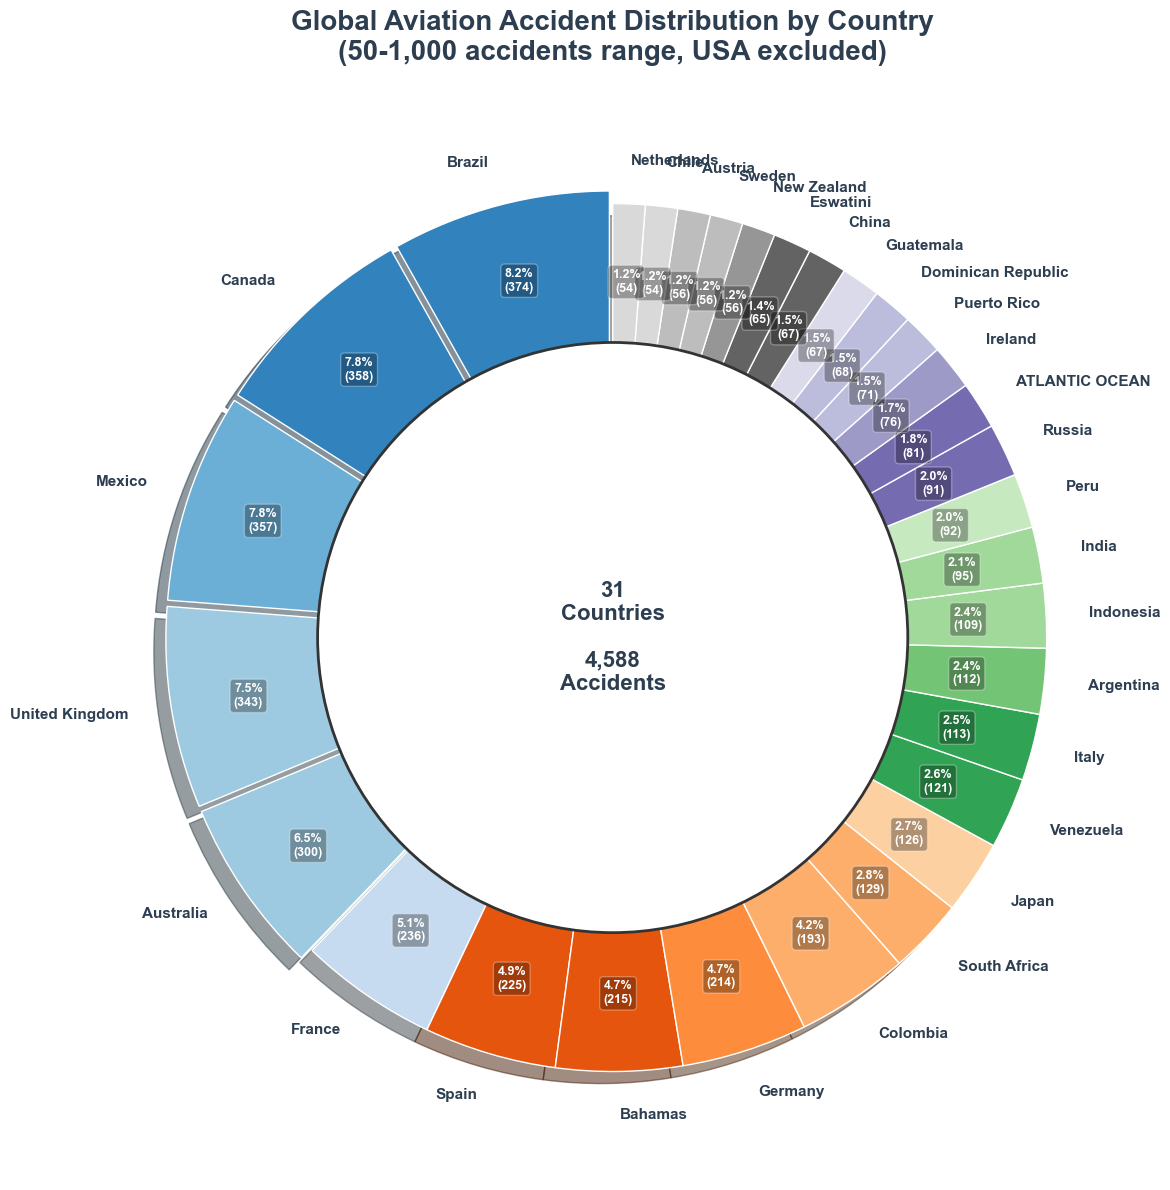

In [18]:
graph_country_data = country_aviation_data[
    (country_aviation_data['number_of_accidents'] > 50) & 
    (country_aviation_data['number_of_accidents'] < 1000)
].copy()

graph_country_data = graph_country_data.sort_values('number_of_accidents', ascending=False)

fig, ax = plt.subplots(figsize=(16, 12), dpi=100)
fig.patch.set_facecolor('white')

colors = plt.cm.tab20c(np.linspace(0, 1, len(graph_country_data)))

wedges, texts, autotexts = ax.pie(
    graph_country_data['number_of_accidents'], 
    labels=graph_country_data['Country'],
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*graph_country_data["number_of_accidents"].sum())})',
    startangle=90,
    colors=colors,
    pctdistance=0.82,
    explode=[0.03 if i < 5 else 0 for i in range(len(graph_country_data))], 
    shadow=True
)

centre_circle = plt.Circle((0, 0), 0.68, fc='white', linewidth=2, edgecolor='#333333')
fig.gca().add_artist(centre_circle)

for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('600')
    text.set_color('#2C3E50')
    
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
    autotext.set_bbox(dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.3))

ax.set_title('Global Aviation Accident Distribution by Country\n(50-1,000 accidents range, USA excluded)', 
             fontsize=20, fontweight='bold', pad=25, color='#2C3E50')

total_shown = graph_country_data['number_of_accidents'].sum()
ax.text(0, 0, f'{len(graph_country_data)}\nCountries\n\n{total_shown:,}\nAccidents', 
        ha='center', va='center', fontsize=16, fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.show()

In [20]:
us_total = country_aviation_data.iloc[0]['number_of_accidents']
print(f"\n{'='*60}")
print(f"📊 GLOBAL AVIATION ACCIDENT DISTRIBUTION")
print(f"{'='*60}")
print(f"🇺🇸 United States: {us_total:,} accidents (excluded from chart)")
print(f"🌍 Countries shown: {len(graph_country_data)}")
print(f"📈 Total in chart: {total_shown:,} accidents")
print(f"🔝 Top 3 countries: {', '.join(graph_country_data.head(3)['Country'].tolist())}")
print(f"{'='*60}")


📊 GLOBAL AVIATION ACCIDENT DISTRIBUTION
🇺🇸 United States: 82,248 accidents (excluded from chart)
🌍 Countries shown: 31
📈 Total in chart: 4,588 accidents
🔝 Top 3 countries: Brazil, Canada, Mexico


### Analysis: Geographic Distribution of Aviation Accidents

**US Dominance:**
The United States accounts for **82,248 accidents (92.5%)** of the total dataset, making it an extreme outlier. This overwhelming proportion reflects:
- The world's largest general aviation fleet
- Highest volume of flight hours globally
- Database primarily sourced from US regulatory authority

**International Distribution (excluding US):**
Among the remaining 6,641 accidents across 31+ countries:

**Key Observations:**
- Countries with strong general aviation cultures (Canada, Australia, Brazil) show higher accident counts
- European nations display relatively lower rates despite significant commercial aviation
- Tourist destinations (Bahamas, Dominican Republic) appear disproportionately represented

## Comprehensive Analysis of Engine Types and Flight Phases

In [26]:
aviation_data.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [29]:
aviation_data["Engine.Type"].value_counts()

Engine.Type
Reciprocating      69530
Turbo Shaft         3609
Turbo Prop          3391
Turbo Fan           2481
Unknown             2051
Turbo Jet            703
Geared Turbofan       12
Electric              10
NONE                   2
LR                     2
Hybrid Rocket          1
UNK                    1
Name: count, dtype: int64

In [28]:
aviation_data[["Investigation.Type", "Aircraft.Category", "Engine.Type", "Broad.phase.of.flight"]]

,Investigation.Type,Aircraft.Category,Engine.Type,Broad.phase.of.flight
0,Accident,NaN,Reciprocating,Cruise
1,Accident,NaN,Reciprocating,Unknown
2,Accident,NaN,Reciprocating,Cruise
3,Accident,NaN,Reciprocating,Cruise
4,Accident,NaN,NaN,Approach
...,...,...,...,...
88884,Accident,NaN,NaN,NaN
88885,Accident,NaN,NaN,NaN
88886,Accident,Airplane,NaN,NaN
88887,Accident,NaN,NaN,NaN


In [21]:
engine_phase_data = aviation_data[['Event.Id', 'Broad.phase.of.flight', 'Engine.Type', 
                                    'Purpose.of.flight', 'Event.Date']].copy()

engine_phase_data['Engine.Type'] = engine_phase_data['Engine.Type'].fillna('Unknown')
engine_phase_data['Engine.Type'] = engine_phase_data['Engine.Type'].replace(
    ['UNK', 'Unknown', 'none', 'None', 'NONE'], 'Unknown'
)

engine_phase_data['Broad.phase.of.flight'] = engine_phase_data['Broad.phase.of.flight'].fillna('Unknown')

In [22]:
graph_engine_phase = engine_phase_data.groupby(['Engine.Type', 'Broad.phase.of.flight']).size().reset_index(name='number_of_accident')
main_engines = ['Turbo Shaft', 'Turbo Prop', 'Turbo Fan', 'Turbo Jet']
main_phases = ['Cruise', 'Takeoff', 'Approach', 'Climb', 'Descent', 'Landing']

graph_engine_phase_filtered = graph_engine_phase[(graph_engine_phase['Engine.Type'].isin(main_engines)) & (graph_engine_phase['Broad.phase.of.flight'].isin(main_phases))]

In [23]:
r_engine_phase = engine_phase_data[engine_phase_data['Engine.Type'] == 'Reciprocating'].groupby(['Broad.phase.of.flight', 'Engine.Type']).size().reset_index(name='number')
r_engine_phase = r_engine_phase[r_engine_phase['Broad.phase.of.flight'].isin(main_phases)]
r_engine_phase = r_engine_phase.sort_values('number', ascending=False)

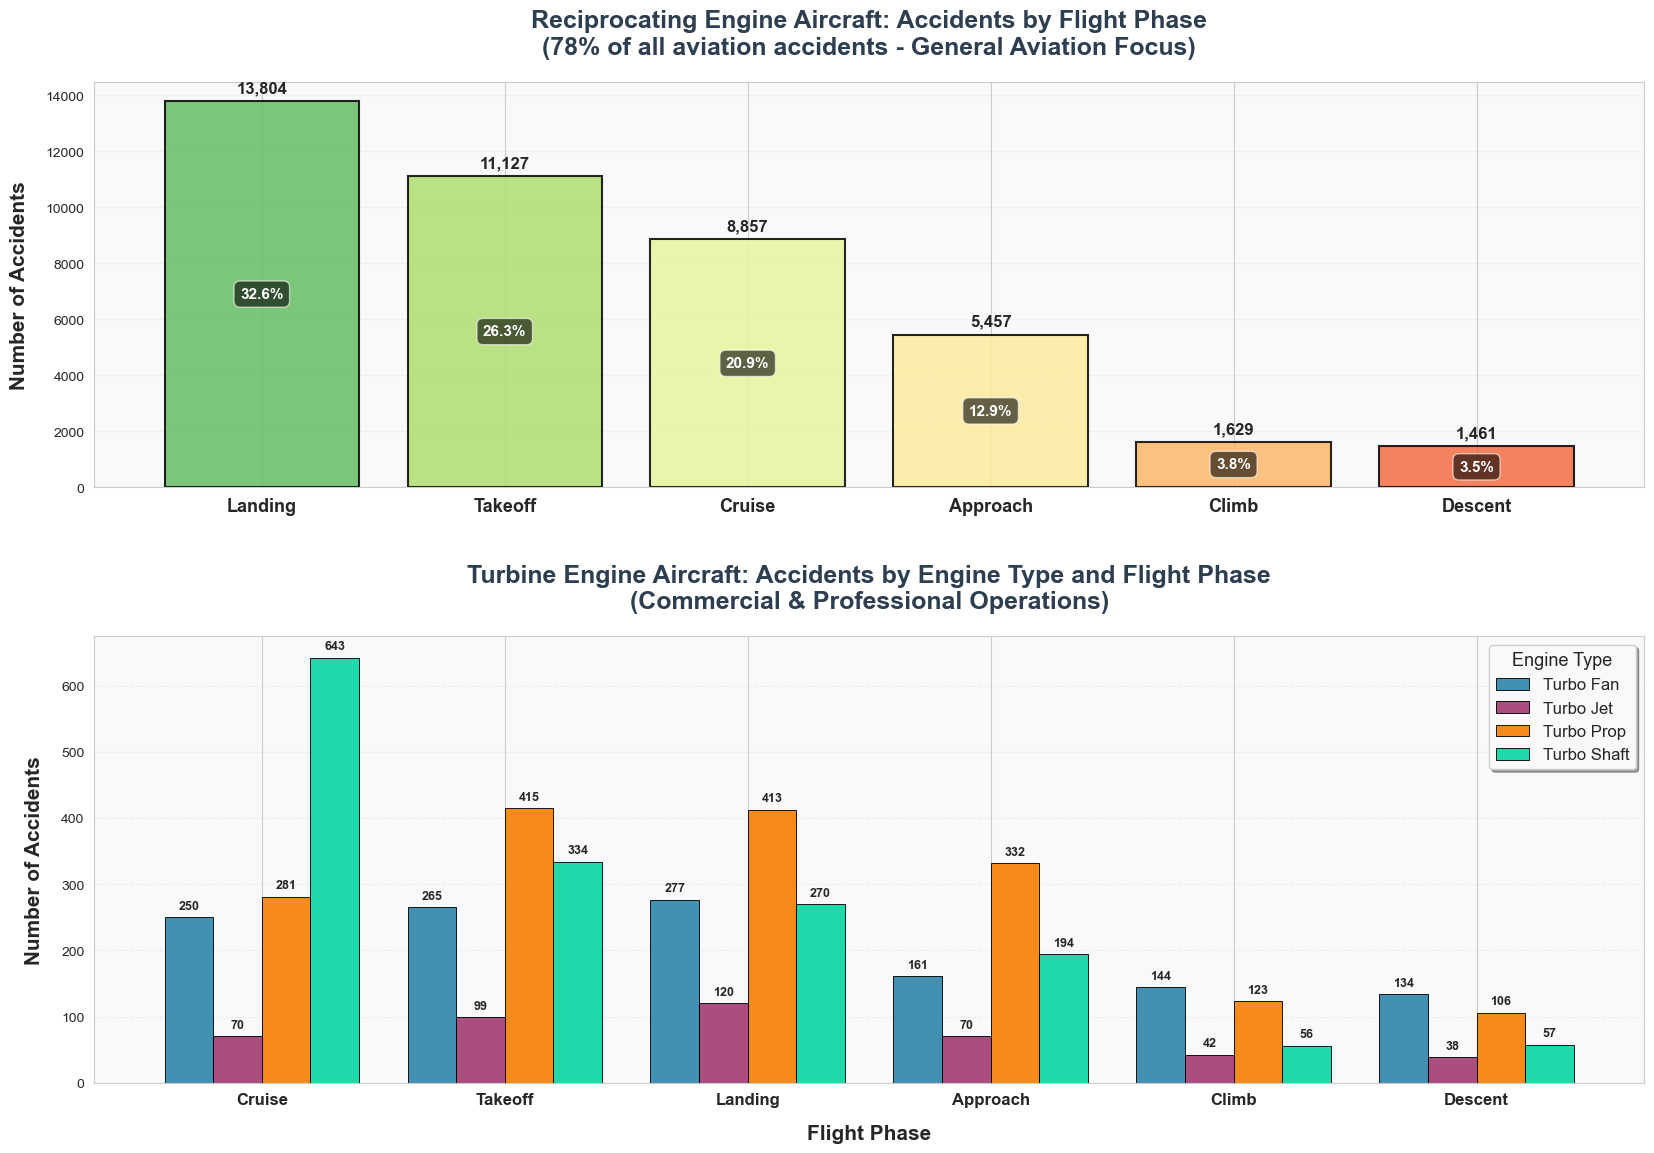


✈️  ENGINE TYPE & FLIGHT PHASE ANALYSIS SUMMARY

🔧 RECIPROCATING ENGINES (General Aviation):
   Total Accidents: 42,335
   Highest Risk Phase: Landing (13,804 accidents)
   Second Highest: Takeoff (11,127 accidents)

⚙️  TURBINE ENGINES (Commercial/Professional):
   Turbo Fan: 1231 total | Peak: Landing (277 accidents)
   Turbo Jet: 439 total | Peak: Landing (120 accidents)
   Turbo Prop: 1670 total | Peak: Takeoff (415 accidents)
   Turbo Shaft: 1554 total | Peak: Cruise (643 accidents)


In [24]:
fig = plt.figure(figsize=(20, 13), dpi=100)
fig.patch.set_facecolor('white')
gs = fig.add_gridspec(2, 1, hspace=0.35, height_ratios=[1, 1.1])

ax1 = fig.add_subplot(gs[0])
r_engine_sorted = r_engine_phase.sort_values('number', ascending=False).reset_index(drop=True)
colors_bubble = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(r_engine_sorted)))
bars = ax1.bar(range(len(r_engine_sorted)), r_engine_sorted['number'], color=colors_bubble, alpha=0.85, edgecolor='black', linewidth=1.5)

for i, (bar, count) in enumerate(zip(bars, r_engine_sorted['number'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 200, f'{int(count):,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_xticks(range(len(r_engine_sorted)))
ax1.set_xticklabels(r_engine_sorted['Broad.phase.of.flight'], fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Accidents', fontsize=15, fontweight='bold', labelpad=12)
ax1.set_title('Reciprocating Engine Aircraft: Accidents by Flight Phase\n(78% of all aviation accidents - General Aviation Focus)', 
              fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
ax1.grid(True, alpha=0.25, axis='y', linestyle='--', linewidth=0.8)
ax1.set_facecolor('#F8F9FA')
ax1.set_axisbelow(True)

total = r_engine_sorted['number'].sum()
for i, count in enumerate(r_engine_sorted['number']):
    pct = (count / total) * 100
    ax1.text(i, count/2, f'{pct:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white', bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.6))

ax2 = fig.add_subplot(gs[1])
pivot_data = graph_engine_phase_filtered.pivot_table(index='Broad.phase.of.flight', columns='Engine.Type', values='number_of_accident', fill_value=0)
phase_totals = pivot_data.sum(axis=1).sort_values(ascending=False)
pivot_data = pivot_data.loc[phase_totals.index]

x = np.arange(len(pivot_data.index))
width = 0.2

colors_engines = {'Turbo Fan': '#2E86AB', 'Turbo Jet': '#A23B72', 'Turbo Prop': '#F77F00', 'Turbo Shaft': '#06D6A0'}
for i, engine in enumerate(pivot_data.columns):
    offset = width * (i - 1.5)
    bars = ax2.bar(x + offset, pivot_data[engine], width, label=engine, color=colors_engines.get(engine, '#999999'), alpha=0.9, edgecolor='black', linewidth=0.7)
    
    for bar in bars:
        height = bar.get_height()
        if height > 10:  
            ax2.text(bar.get_x() + bar.get_width()/2., height + 8, f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')   
                        

ax2.set_xlabel('Flight Phase', fontsize=15, fontweight='bold', labelpad=12)
ax2.set_ylabel('Number of Accidents', fontsize=15, fontweight='bold', labelpad=12)
ax2.set_title('Turbine Engine Aircraft: Accidents by Engine Type and Flight Phase\n(Commercial & Professional Operations)', 
              fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
ax2.set_xticks(x)
ax2.set_xticklabels(pivot_data.index, fontsize=12, fontweight='bold')
ax2.legend(title='Engine Type', fontsize=12, title_fontsize=13, loc='upper right', framealpha=0.95, shadow=True)
ax2.grid(True, alpha=0.25, axis='y', linestyle='--', linewidth=0.8)
ax2.set_facecolor('#F8F9FA')
ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"✈️  ENGINE TYPE & FLIGHT PHASE ANALYSIS SUMMARY")
print(f"{'='*70}")
print(f"\n🔧 RECIPROCATING ENGINES (General Aviation):")
print(f"   Total Accidents: {r_engine_sorted['number'].sum():,}")
print(f"   Highest Risk Phase: {r_engine_sorted.iloc[0]['Broad.phase.of.flight']} ({r_engine_sorted.iloc[0]['number']:,} accidents)")
print(f"   Second Highest: {r_engine_sorted.iloc[1]['Broad.phase.of.flight']} ({r_engine_sorted.iloc[1]['number']:,} accidents)")
print(f"\n⚙️  TURBINE ENGINES (Commercial/Professional):")
for engine in pivot_data.columns:
    total = pivot_data[engine].sum()
    max_phase = pivot_data[engine].idxmax()
    max_count = pivot_data[engine].max()
    print(f"   {engine}: {int(total)} total | Peak: {max_phase} ({int(max_count)} accidents)")
print(f"{'='*70}")

### Analysis: Engine Type and Flight Phase Risk Patterns

**Reciprocating Engine Dominance (78% of all accidents):**

Reciprocating engines, predominantly found in general aviation aircraft, show distinct risk patterns:

1. **Landing Phase - Highest Risk (13,804 accidents, 32.5%)**
   - Most critical phase for piston engine aircraft
   - Factors: Engine management during power reduction, crosswinds, pilot error
   - Density altitude effects on performance

2. **Takeoff Phase - Second Highest (11,127 accidents, 26.2%)**
   - High power demand exposes engine limitations
   - Critical phase with limited altitude for emergency response
   - Weight and balance issues most apparent

3. **Cruise Phase (8,857 accidents, 20.9%)**
   - Despite being longest phase, shows moderate accident rate
   - Often involves fuel management issues or mechanical failures

**Turbine Engine Patterns:**

**Turbo Shaft (Helicopter engines):**
- **Cruise dominance (643 accidents)**: Unique among all engine types
- Reflects helicopter operational profile (extended hover/cruise operations)
- Landing (270) and Takeoff (334) show balanced risk distribution

**Turbo Prop:**
- **Relatively balanced across phases** (Landing: 413, Takeoff: 415, Approach: 332)
- Used in regional aircraft with professional crews
- Shows better performance consistency than reciprocating engines

**Turbo Fan (Large commercial aircraft):**
- **Landing slight edge (277)** over Takeoff (265) and Cruise (250)
- Most evenly distributed risk profile
- Reflects high reliability and professional operation
- Lower absolute numbers despite high flight hours (better safety record)

**Turbo Jet:**
- Similar pattern to Turbo Fan but smaller numbers
- Landing (120) > Takeoff (99) > Cruise/Approach (70 each)

**Key Safety Insights:**

1. **Critical Phases Apply Universally**: Regardless of engine type, landing and takeoff remain the highest-risk phases, accounting for 50-60% of accidents

2. **Engine Technology Impact**: Turbine engines show more balanced risk distribution across phases compared to reciprocating engines, suggesting better reliability and performance consistency

3. **Reciprocating Engine Concerns**: The overwhelming concentration of accidents in landing phase (32.5%) for reciprocating engines indicates need for:
   - Enhanced landing training emphasis
   - Better engine management procedures
   - Improved go-around decision making

4. **Operational Context Matters**: Turbo shaft's cruise-phase concentration reflects unique helicopter operations, emphasizing the importance of considering aircraft mission profiles in safety analysis